## What Is Overfitting?

### What does it mean for a model to overfit?
- A model overfits when it learns both the underlying patterns and the noise present in the training data, resulting in excellent training performance but poor generalization to unseen data.

### How is overfitting different from high training loss?
- High training loss indicates that the model has not fit the training data well. This often leads to poor performance on both training and unseen data and is commonly associated with underfitting.

### Why can training accuracy increase while validation accuracy decreases?
- As training continues, the model begins fitting training-specific noise and spurious patterns instead of only the underlying relationship. Training accuracy continues to improve because those patterns exist in the training data, but validation accuracy decreases because those patterns do not generalize.

## Bias–Variance Revisited

### How does overfitting relate to the bias–variance tradeoff you learned in classical ML?
- Overfitting is a manifestation of the high-variance side of the bias–variance tradeoff. As model complexity increases, bias decreases because the model fits the training data better. However, variance increases because the model becomes sensitive to small variations and noise in the training data, reducing its ability to generalize.
- Bias measures how far off, on average, a model’s predictions are from the ground truth values.
- Variance measures how much a model’s predictions change with different training datasets.
 
### Why does the same concept still apply to neural networks?
- Neural networks are still function approximators. They learn a mapping from inputs to outputs just like linear regression, decision trees, or random forests. Therefore, they face the same tradeoff between fitting the training data and generalizing to unseen data. The difference is that neural networks usually have much higher capacity, making them more susceptible to overfitting if regularization is not used.

## Detecting Overfitting

### Fetching, Scaling and Creating dataset than dataloader

In [1]:
from sklearn.datasets import load_wine

data = load_wine()
X = data.data
y = data.target

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

import torch

x_train_scaled = torch.tensor(x_train_scaled, dtype=torch.float32)
x_test_scaled = torch.tensor(x_test_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

from torch.utils.data import Dataset, DataLoader

class SimpleDataset(Dataset):
    def __init__(self):
        super().__init__()
        self.X = x_train_scaled
        self.y = y_train
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]

dataset = SimpleDataset()

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

### Creating neural network model for Wine classification which is Oversized 

In [2]:
class WineClassifierOversized(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.ReLU = torch.nn.ReLU()
        self.fc1 = torch.nn.Linear(13, 256)
        self.fc2 = torch.nn.Linear(256, 128)
        self.fc3 = torch.nn.Linear(128, 64)
        self.fc4 = torch.nn.Linear(64, 3)
        
    def forward(self, x):
        
        x = self.fc1(x)
        x = self.ReLU(x)
        x = self.fc2(x)
        x = self.ReLU(x)
        x = self.fc3(x)
        x = self.ReLU(x)
        x = self.fc4(x)
        
        return x

### Creating model training loop and packing it into function.

In [3]:
from typing import List, Tuple

def train_model(model, loader, optimizer, loss_fn, epochs=40)  -> Tuple[List, List]:

    train_losses = []
    validation_losses = []

    for epoch in range(epochs):
        train_loss = 0
        validation_loss = 0
        
        model.train()
        
        for x_batch, y_batch in loader:
            
            pred = model(x_batch)
            
            loss = loss_fn(pred, y_batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
        model.eval()
        
        with torch.no_grad():
            
            pred = model(x_test_scaled)
            
            validation_loss = loss_fn(pred, y_test)
        
        train_loss = train_loss / len(loader)
        
        train_losses.append(train_loss)
        validation_losses.append(validation_loss)
        
    print("training complete")
        
    return validation_losses, train_losses

### Training model without modification

In [4]:
model = WineClassifierOversized()        

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

validation_losses, train_losses = train_model(model, loader, optimizer, loss_fn)

for i in range(len(validation_losses)):
    print(f"Epoch: {i+1:02}, training_loss: {train_losses[i]:.4f}, validation_loss: {validation_losses[i]:.4f}")

training complete
Epoch: 01, training_loss: 1.0306, validation_loss: 0.9071
Epoch: 02, training_loss: 0.8388, validation_loss: 0.6640
Epoch: 03, training_loss: 0.5792, validation_loss: 0.3996
Epoch: 04, training_loss: 0.3180, validation_loss: 0.2010
Epoch: 05, training_loss: 0.1572, validation_loss: 0.1021
Epoch: 06, training_loss: 0.0708, validation_loss: 0.0726
Epoch: 07, training_loss: 0.0365, validation_loss: 0.0574
Epoch: 08, training_loss: 0.0204, validation_loss: 0.0372
Epoch: 09, training_loss: 0.0169, validation_loss: 0.0312
Epoch: 10, training_loss: 0.0075, validation_loss: 0.0505
Epoch: 11, training_loss: 0.0047, validation_loss: 0.0630
Epoch: 12, training_loss: 0.0040, validation_loss: 0.0582
Epoch: 13, training_loss: 0.0029, validation_loss: 0.0425
Epoch: 14, training_loss: 0.0020, validation_loss: 0.0306
Epoch: 15, training_loss: 0.0017, validation_loss: 0.0263
Epoch: 16, training_loss: 0.0016, validation_loss: 0.0267
Epoch: 17, training_loss: 0.0014, validation_loss: 0.0

### What trend indicates overfitting?
- When training loss keeps decreasing and validation loss starts increasing.

### At what epoch does validation loss stop improving?
- After some epoch it starts increasing instead of decreasing.

## Train vs Validation Curves

In [5]:
print(f"avg_validation_loss: {float(sum(validation_losses)/len(validation_losses)):.4f}")
print(f"avg_train_loss: {sum(train_losses)/len(train_losses):.4f}")

avg_validation_loss: 0.0932
avg_train_loss: 0.0777


### Making a function to plot train and validation losses

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_train_val_loss_curve(train_losses, validation_losses, title):
    
    train_losses = np.array(train_losses)
    validation_losses = np.array(validation_losses)

    train_min_idx = np.argmin(train_losses)
    val_min_idx = np.argmin(validation_losses)

    plt.plot(validation_losses, label='Validation Loss')
    plt.plot(train_losses, label="Training Loss")

    plt.scatter(train_min_idx, train_losses[train_min_idx])
    plt.scatter(val_min_idx, validation_losses[val_min_idx])

    plt.annotate(
        f"Epoch {val_min_idx}\n{validation_losses[val_min_idx]:.4f}",
        (float(val_min_idx), validation_losses[val_min_idx]),
        xytext=(10, 10),
        textcoords="offset points",
    )

    plt.annotate(
        f"Epoch {train_min_idx}\n{train_losses[train_min_idx]:.4f}",
        (float(train_min_idx), train_losses[train_min_idx]),
        xytext=(10, -15),
        textcoords="offset points",
    )

    plt.legend()
    plt.title(title)
    plt.show()

### Plotting Train vs Validation curve for model without dropout

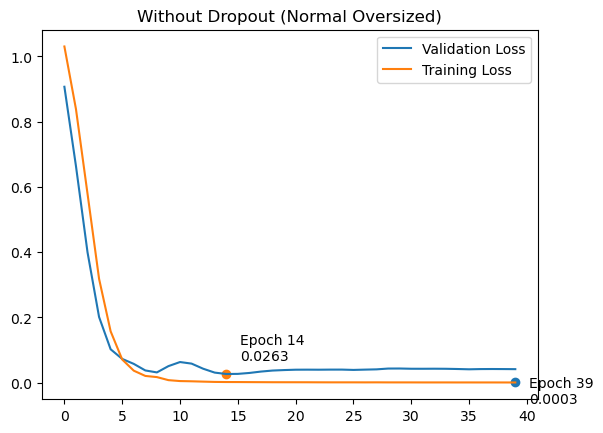

In [7]:
plot_train_val_loss_curve(train_losses, validation_losses, "Without Dropout (Normal Oversized)")

- some times the training set is essentially memorized so further parameter updates are very small thus validation performance therefore changes very little but this is still overfitting.

### Why are these curves more informative than final accuracy?
- Training and validation loss curves show how learning evolves over time, not just the final outcome. They reveal whether the model is still learning useful patterns, has converged, or has begun overfitting. Final accuracy cannot tell you when those changes occurred.

- Accuracy is one number but Learning curves show the entire training process.

### What does divergence between the curves indicate?
- Divergence indicates that the model continues reducing training error while its performance on unseen data worsens. This means additional learning is focused on training-specific details rather than generalizable patterns.

## Early Stopping

- Early stopping is a regularization technique where training is stopped once the validation performance stops improving, even if training performance continues to improve.

### What problem does early stopping solve?
- Early stopping reduces overfitting by preventing the model from continuing to optimize the training data after validation performance has peaked.

### Why is the best model not always the last epoch?
- The best model is the one with the lowest validation loss (or highest validation metric), not necessarily the one trained for the most epochs. After that point, additional training may only improve training performance while degrading generalization.

## Dropout

### Creating neural network model for Wine classification which is Oversized and has Dropout

In [8]:
class WineClassifierOversizedWithDropout(torch.nn.Module):
    def __init__(self):
        super().__init__()
        
        self.ReLU = torch.nn.ReLU()
        self.Dropout = torch.nn.Dropout(p=0.7)
        self.fc1 = torch.nn.Linear(13, 256)
        self.fc2 = torch.nn.Linear(256, 128)
        self.fc3 = torch.nn.Linear(128, 64)
        self.fc4 = torch.nn.Linear(64, 3)
        
    def forward(self, x):
        
        x = self.fc1(x)
        x = self.ReLU(x)
        x = self.Dropout(x)
        x = self.fc2(x)
        x = self.ReLU(x)
        x = self.Dropout(x)
        x = self.fc3(x)
        x = self.ReLU(x)
        x = self.Dropout(x)
        x = self.fc4(x)
        
        return x

### Training model with Dropout

In [9]:
model = WineClassifierOversizedWithDropout()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

validation_losses, train_losses = train_model(model, loader, optimizer, loss_fn, epochs=60)

print(f"avg_validation_loss: {float(sum(validation_losses)/len(validation_losses)):.4f}")
print(f"avg_train_loss: {sum(train_losses)/len(train_losses):.4f}")

training complete
avg_validation_loss: 0.2298
avg_train_loss: 0.2938


### Plotting Train vs Validation curve for model with dropout

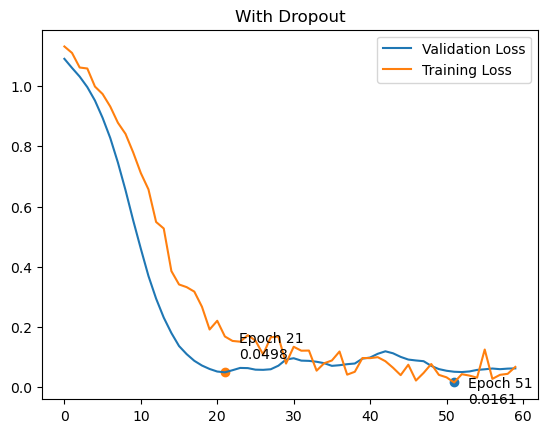

In [10]:
plot_train_val_loss_curve(train_losses, validation_losses, "With Dropout")

- nn.Dropout is a regularization layer that randomly sets a fraction of a layer's activations to zero during training, reducing co-adaptation between neurons and improving generalization.

### What happens during training?
- During training, dropout randomly sets a fraction of neuron activations to zero on each forward pass. Every mini-batch therefore trains a slightly different network.

### What changes during evaluation?
- Dropout is active only during training; it is automatically disabled when the model is set to evaluation mode (model.eval())

### Why does dropout reduce overfitting?
- Dropout prevents neurons from becoming overly dependent on one another (co-adaptation). Because different neurons are removed on each forward pass, the network is forced to distribute useful representations across multiple neurons, making it more robust and improving generalization.

## Weight Decay (L2 Regularization)

### Training model with Dropout and optimizer is having weight_decay of 0.1

In [11]:
model = WineClassifierOversizedWithDropout()

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    weight_decay=0.1,
    lr=0.001
)

validation_losses, train_losses = train_model(model, loader, optimizer, loss_fn)

print(f"avg_validation_loss: {float(sum(validation_losses)/len(validation_losses)):.4f}")
print(f"avg_train_loss: {sum(train_losses)/len(train_losses):.4f}")

training complete
avg_validation_loss: 0.5119
avg_train_loss: 0.6070


### Plotting Train vs Validation curve for model With Dropout and Optimizer having weight_decay of 0.1

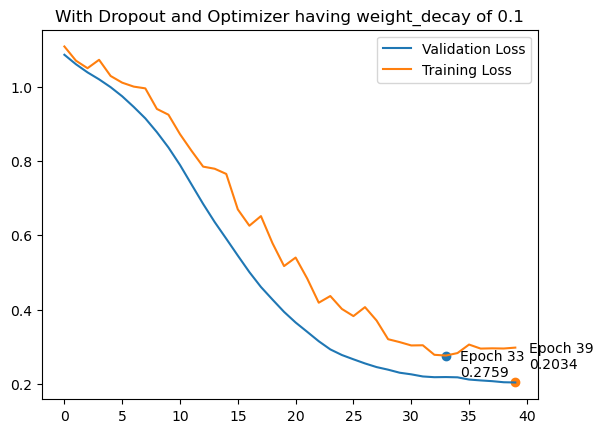

In [12]:
plot_train_val_loss_curve(train_losses, validation_losses, "With Dropout and Optimizer having weight_decay of 0.1")

### Training model without Dropout and optimizer is having weight_decay of 0.1

In [13]:
model = WineClassifierOversized()

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    weight_decay=0.1,
    lr=0.001
)

validation_losses, train_losses = train_model(model, loader, optimizer, loss_fn)

print(f"avg_validation_loss: {float(sum(validation_losses)/len(validation_losses)):.4f}")
print(f"avg_train_loss: {sum(train_losses)/len(train_losses):.4f}")

training complete
avg_validation_loss: 0.3042
avg_train_loss: 0.3074


### Plotting Train vs Validation curve for model Without Dropout and Optimizer having weight_decay of 0.1

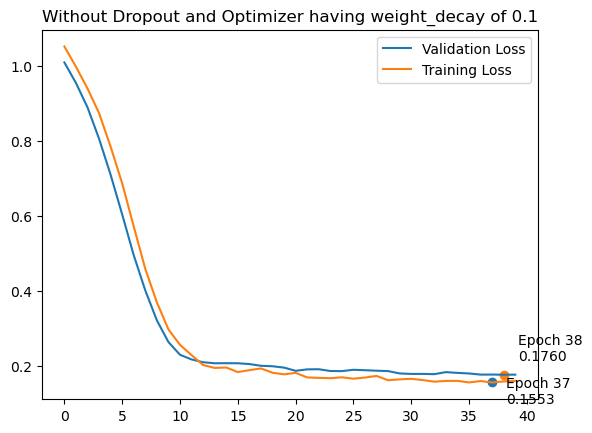

In [14]:
plot_train_val_loss_curve(train_losses, validation_losses, "Without Dropout and Optimizer having weight_decay of 0.1")

- Since when training with weight_decay both model with or without dropout are reaching validation loss of approx. 0.2 but model without dropout is more stable. Now i will decrease weight_decay and use mode without dropout. Because weight decay is generally smaller near 1e-3(0.001), 1e-4(0.0001).

### Training model without Dropout and optimizer is having weight_decay of 1e-3 (100 times smaller than 0.1) (0.001)

In [15]:
model = WineClassifierOversized()

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    weight_decay=1e-3,
    lr=0.001
)

validation_losses, train_losses = train_model(model, loader, optimizer, loss_fn)

print(f"avg_validation_loss: {float(sum(validation_losses)/len(validation_losses)):.4f}")
print(f"avg_train_loss: {sum(train_losses)/len(train_losses):.4f}")

training complete
avg_validation_loss: 0.1167
avg_train_loss: 0.0829


### Plotting Train vs Validation curve for model Without Dropout and Optimizer having weight_decay of 1e-3

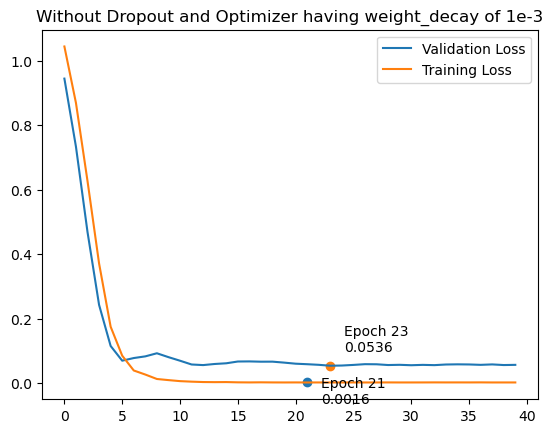

In [16]:
plot_train_val_loss_curve(train_losses, validation_losses, "Without Dropout and Optimizer having weight_decay of 1e-3")

### Training model without Dropout and optimizer is having weight_decay of 1e-2 (10 times smaller than 0.1) (0.01)

In [17]:
model = WineClassifierOversized()

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    weight_decay=1e-2,
    lr=0.001
)

validation_losses, train_losses = train_model(model, loader, optimizer, loss_fn)

print(f"avg_validation_loss: {float(sum(validation_losses)/len(validation_losses)):.4f}")
print(f"avg_train_loss: {sum(train_losses)/len(train_losses):.4f}")

training complete
avg_validation_loss: 0.1271
avg_train_loss: 0.0928


### Plotting Train vs Validation curve for model With Dropout and Optimizer having weight_decay of 1e-2

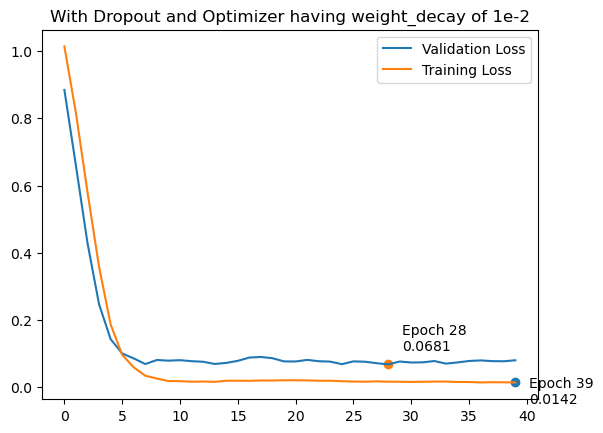

In [18]:
plot_train_val_loss_curve(train_losses, validation_losses, "With Dropout and Optimizer having weight_decay of 1e-2")

- Weight decay penalizes large weights by adding an L2 penalty to the loss function. During optimization, the model learns weights that balance prediction accuracy with keeping weight magnitudes small.

### How does weight decay differ from dropout?
- Dropout randomly sets neuron activations to zero during training, temporarily disabling parts of the network. Weight decay never disables neurons; instead, it continuously encourages the model to learn smaller weights by penalizing large weight values.

### Why discourage very large weights?
- By keeping the weight small we forces the model to rely less on individual connections becoming extremely influential also prevents it from memorizing noise in the data.

- By constraining weight magnitudes, weight decay promotes simpler, smoother models that generalize better to unseen data, reducing variance without significantly increasing bias. 


## Model Capacity

### Training small model

In [19]:
class WineClassifierSmall(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.ReLU = torch.nn.ReLU()
        self.fc1 = torch.nn.Linear(13, 6)
        self.fc2 = torch.nn.Linear(6, 3)
        
    def forward(self, x):
        
        x = self.fc1(x)
        x = self.ReLU(x)
        x = self.fc2(x)
        
        return x

In [20]:
model = WineClassifierSmall()

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

validation_losses, train_losses = train_model(model, loader, optimizer, loss_fn, epochs=1500)

print(f"avg_validation_loss: {float(sum(validation_losses)/len(validation_losses)):.4f}")
print(f"avg_train_loss: {sum(train_losses)/len(train_losses):.4f}")

training complete
avg_validation_loss: 0.0669
avg_train_loss: 0.0340


### Plotting Train vs Validation curve for model Without Dropout very small model

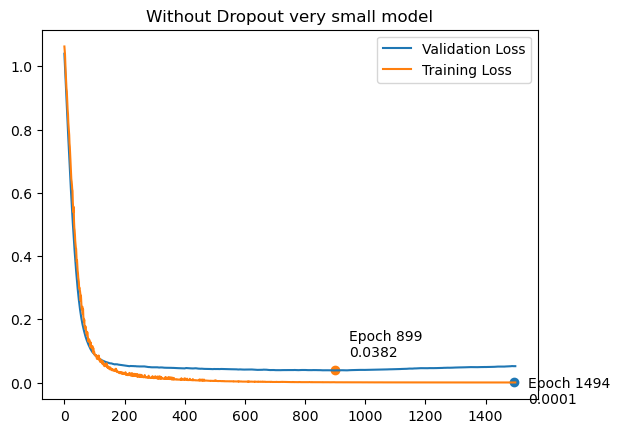

In [21]:
plot_train_val_loss_curve(train_losses, validation_losses, "Without Dropout very small model")

### Training medium model

In [22]:
class WineClassifierMedium(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.ReLU = torch.nn.ReLU()
        self.fc1 = torch.nn.Linear(13, 8)
        self.fc2 = torch.nn.Linear(8, 4)
        self.fc3 = torch.nn.Linear(4, 3)
        
    def forward(self, x):
        
        x = self.fc1(x)
        x = self.ReLU(x)
        x = self.fc2(x)
        x = self.ReLU(x)
        x = self.fc3(x)
        
        return x

In [23]:
model = WineClassifierMedium()

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

validation_losses, train_losses = train_model(model, loader, optimizer, loss_fn, epochs=1500)

print(f"avg_validation_loss: {float(sum(validation_losses)/len(validation_losses)):.4f}")
print(f"avg_train_loss: {sum(train_losses)/len(train_losses):.4f}")

training complete
avg_validation_loss: 0.1134
avg_train_loss: 0.0452


### Plotting Train vs Validation curve for model without dropout medium model

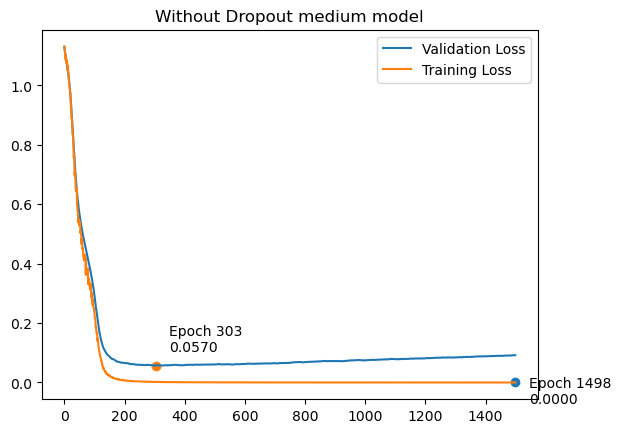

In [24]:
plot_train_val_loss_curve(train_losses, validation_losses, "Without Dropout medium model")

### Training oversized model

In [25]:
class WineClassifierOversized(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.ReLU = torch.nn.ReLU()
        self.fc1 = torch.nn.Linear(13, 256)
        self.fc2 = torch.nn.Linear(256, 128)
        self.fc3 = torch.nn.Linear(128, 3)
        
    def forward(self, x):
        
        x = self.fc1(x)
        x = self.ReLU(x)
        x = self.fc2(x)
        x = self.ReLU(x)
        x = self.fc3(x)
        
        return x

In [26]:
model = WineClassifierOversized()

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

validation_losses, train_losses = train_model(model, loader, optimizer, loss_fn, epochs=100)

print(f"avg_validation_loss: {float(sum(validation_losses)/len(validation_losses)):.4f}")
print(f"avg_train_loss: {sum(train_losses)/len(train_losses):.4f}")

training complete
avg_validation_loss: 0.0773
avg_train_loss: 0.0285


### Plotting Train vs Validation curve for model without dropout oversized model

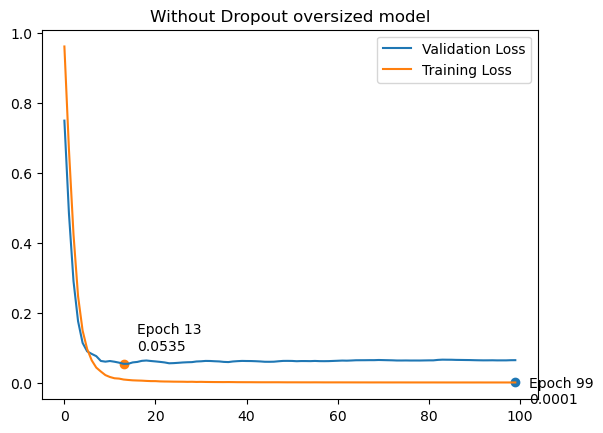

In [27]:
plot_train_val_loss_curve(train_losses, validation_losses, "Without Dropout oversized model")

### Which overfits first?
- Oversized model overfits first then the medium model and than small it makes sense because a smaller model has lower capacity, so it is less likely to memorize noise. If its capacity is sufficient for the underlying problem, it may generalize better than a larger model. However, if its capacity is too low, it may underfit and fail to learn the underlying patterns. Medium model has enough model capacity to capture the underling patters and it can overfit the training dataset and oversized model has more than enough model capacity to capture noise or memorize the data.

### Why doesn't a larger model always perform better?
- Because large model are tend to capture noise and memorize data due to their large model capacity and in case where dataset does not contain enough information to justify the additional capacity or does not contain complex patterns, model will overfit the data and will not perform better on unseen data than small or medium model.

- Larger models have greater capacity and therefore require stronger regularization and more data to generalize well.

## Hyperparameter Reflection

### How does each influence overfitting?

- effects are only true if all the other things are remains unchanged. 

- number of layers: Increasing the number of layers generally increases the model's representational capacity, allowing it to learn more complex functions. If the additional capacity exceeds the complexity of the problem, the risk of overfitting increases.

- hidden units: Increasing the number of hidden units increases model capacity. If the dataset does not require that capacity, the model becomes more likely to memorize training-specific patterns and overfit.

- learning rate: Learning rate controls the size of parameter updates during optimization. It primarily affects training stability and convergence speed rather than model capacity. However, an inappropriate learning rate can make overfitting appear worse or mask the true behavior of the model.

- epochs: Increasing the number of training epochs allows the model to continue fitting the training data. After the model has learned the underlying patterns, additional epochs may cause it to memorize training-specific noise, leading to overfitting.

- dropout: Dropout randomly sets a fraction of neuron activations to zero during training, preventing neurons from becoming overly dependent on one another and improving generalization.

- weight decay: Weight decay penalizes the large weight thus forcing model to rely less on individual high-magnitude connections and ultimately reduce overfitting. 